# Assemble Flow Cytometry CyAnno Cell Type Frequencies

In this notebook, we read our CyAnno summary files and clinical labs, and use these to produce frequencies and proportions of cell types at each of our cell type labeling levels for each sample.

These results are combined with sample-specific metadata to enable downstream analysis and comparisons. We also incorporate ontological relationships between the population labels assigned using CyAnno and our scRNA-seq-derived population labels (AIFI_L1, AIFI_L2, and AIFI_L3). These are not always 1:1 relationships, so we specify whether each flow cytometry population is "equivalent to" or a "subset of" the corresponding scRNA-seq population.

There are four different flow cytometry panels, each of which has two levels of cell population annotation:  
`CyAnno_L1` is a broad label that is common across all panels.  
`CyAnno_PXX` (where PXX is PB1, PM1, PS1, or PT1) defines higher-resolution, panel-specific cell populations. These are not necessarily the same across panels due to differences in the features available.  

In addition to computing counts/frequency and fraction of total cells per sample, we use the Absolute Lymphocyte Counts from Clinical Blood Counts performed on the same blood draws to estimate absolute cell counts for each sample. This is done by computing the ratio between the lymphocyte counts in the scRNA-seq data and the ALC to get an Absolute count per Flow Cytometry count correction factor, and then multiplying this ratio by the number of cells observed for each cell type:

$$C_{type} = N_{type} * {{ALC}\over N_{Tcells} + N_{Bcells} + N_{NKcells}}$$

$ALC$: Absolute lymphocyte count from complete blood counts  
$C_{type}$: Estimated absolute count for a specific type  
$N_{type}$: count of cells in a specific population defined by Flow Cytometry  
$N_{Tcells} + N_{Bcells} + N_{NKcells}$: count of lymphocytes in Flow Cytometry sample

## Output format
Outputs include the following columns:  

**Process-related columns**  
`file.id`: A unique identifier for the originating CyAnno cell population count output file  
`file.batchID`: A unique identifier for the sample batch - can be used to match to bridging controls  
`file.panel`: An identifier for the flow cytometry antibody panel utilized to generate population counts (PB1, PM1, PS1, or PT1)  

**Sample Metadata columns**  
`cohort.cohortGuid`: Cohort ID (BR1, BR2, or UP1)  
`subject.subjectGuid`: Subject ID  
`subject.biologicalSex`: Subject Sex (Female or Male)  
`subject.cmv`: Subject CMV Status (Negative or Positive)  
`subject.bmi`: Subject BMI (integer)  
`subject.race`: Subject race  
`subject.ethnicity`: Subject ethnicity  
`subject.birthYear`: Subject Birth Year  
`subject.ageAtFirstDraw`: Subject Age at earliest blood draw in study  
`sample.sampleKitGuid`: Sample Kit ID  
`sample.visitName`: Sample Visit Name  
`sample.drawDate`: Sample Draw Date (Year-Month)  
`sample.subjectAgeAtDraw`: Subject age at time of draw, based on year of Draw Date and Birth Year  
`specimen.specimenGuid`: Specimen ID (pbmc_sample_id in .h5 files)  
  
**Frequency-related columns**  

`CyAnno_L1`: Broad population label   
`CyAnno_PXX`: Finer, panel-specific population label (see above)  
`total_live_events`: Total live events used as input for labeling  
`total_cells`: Count of events labeled as a known cell type by CyAnno, excluding the "Debris" and "Unknown" labels
`flow.lymphocyte_count`: Sum of T, NK, and B cells  
`bc.lymphocyte_count`: Absolute Lymphocyte Count (ALC) from clinical Blood Counts (bc.)  
`alc_ratio`: ALC per Flow Cytometry Lymphocyte Count  
`CyAnno_PXX_frac_live_events`: Fraction of events with cell type assignment divided by `total_live_events` for this sample  
`CyAnno_PXX_frac_cells`: Fraction of cells with cell type assignment divided by `total_cells` for this sample  
`CyAnno_PXX_alc`: ALC estimate for this population  
`CyAnno_PXX_clr`: Centered Log Ratio computed using CyAnno_PXX_frac_total  

**Ontology relationship columns**
These columns specify relationships between the cell types defined by CyAnno and the scRNA-seq cell types defined in the Human Immune Health Atlas. When there is not a corresponding cell type at a given level of resolution a missing value (NA) is provided.

`AIFI_L1_relationship`: Relationship between the `Cyanno_PXX` population and the specified `AIFI_L1` population label  
`AIFI_L1`: scRNA-seq AIFI_L1 population related to CyAnno population  
`AIFI_L2_relationship`: Relationship between the `Cyanno_PXX` population and the specified `AIFI_L2` population label  
`AIFI_L2`:  scRNA-seq AIFI_L2 population related to CyAnno population  
`AIFI_L3_relationship`: Relationship between the `Cyanno_PXX` population and the specified `AIFI_L3` population label  
`AIFI_L3`:  scRNA-seq AIFI_L3 population related to CyAnno population  


In [1]:
quiet_library <- function(...) { suppressPackageStartupMessages(library(...)) }
quiet_library(hise)
quiet_library(dplyr)
quiet_library(purrr)
quiet_library(nanoparquet)
quiet_library(ggplot2)

In [2]:
if(!dir.exists("output")) {
    dir.create("output")
}

CLR Transformation function from Qiuyu Gong and  Mansi Singh

In [3]:
clr_transform <- function(x) {
  if (length(x) == 0) {
    return(NA)  # return NA for empty vectors
  }
  geom_mean <- exp(mean(log(x)))
  return(log(x / geom_mean))
}

### Retrieve sample information

In [4]:
sample_meta_file_uuid = '4201fbb0-e6a3-4d30-a076-41b3e9ac1b9b'

In [5]:
sample_meta_file <- cacheFiles(list(sample_meta_file_uuid))

[1] "downloading fileID 4201fbb0-e6a3-4d30-a076-41b3e9ac1b9b"


In [6]:
sample_meta <- read.csv(sample_meta_file, row.names = 1)

In [7]:
nrow(sample_meta)

[1] 108

In [8]:
names(sample_meta)

[1] "cohort.cohortGuid"          "subject.subjectGuid"       
 [3] "subject.biologicalSex"      "subject.cmv"               
 [5] "subject.bmi"                "subject.race"              
 [7] "subject.ethnicity"          "subject.birthYear"         
 [9] "subject.ageAtFirstDraw"     "sample.sampleKitGuid"      
[11] "sample.visitName"           "sample.drawDate"           
[13] "sample.subjectAgeAtDraw"    "sample.daysSinceFirstVisit"
[15] "specimen.specimenGuid"      "pipeline.fileGuid"

### Retrieve clinical labs

In [9]:
labs_uuid <- '046c1c7f-e820-47bb-b407-62469057a5b4'

In [10]:
labs_file <- cacheFiles(list(labs_uuid))

[1] "downloading fileID 046c1c7f-e820-47bb-b407-62469057a5b4"


In [11]:
labs <- read.csv(labs_file)

In [12]:
nrow(labs)

[1] 108

In [13]:
alc_labs <- labs %>%
  select(sample.sampleKitGuid, Absolute.Lymphocyte.Count..ALC.) %>%
  rename("bc.absolute_lymphocyte_count" = "Absolute.Lymphocyte.Count..ALC.")

In [14]:
head(alc_labs)

,sample.sampleKitGuid,bc.absolute_lymphocyte_count
,<chr>,<dbl>
1,KT00001,1337
2,KT00002,2173
3,KT00003,1861
4,KT00004,1444
5,KT00006,1406
6,KT00010,1412


#### Remove Abnormal value
One subject has a reported ALC > 10-fold above the normal range. This appears to be a data entry error. For the purposes of computing estimated ALC, we'll remove this value.

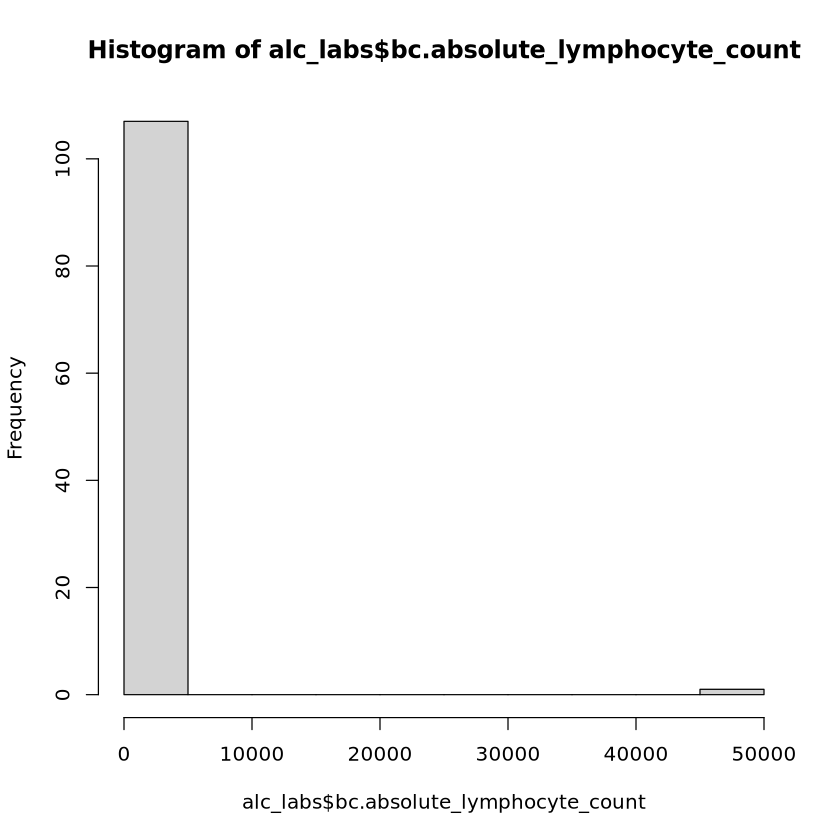

In [15]:
hist(alc_labs$bc.absolute_lymphocyte_count)

In [16]:
alc_labs %>%
  filter(bc.absolute_lymphocyte_count == 47600)

sample.sampleKitGuid,bc.absolute_lymphocyte_count
<chr>,<dbl>
KT00928,47600


In [17]:
quantile(alc_labs$bc.absolute_lymphocyte_count, seq(0, 1, 0.1))

0%     10%     20%     30%     40%     50%     60%     70%     80%     90% 
  587.0  1203.1  1385.0  1501.1  1583.8  1724.5  1855.4  2019.8  2281.2  2660.0 
   100% 
47600.0

In [18]:
alc_labs <- alc_labs %>%
  filter(bc.absolute_lymphocyte_count != 47600)

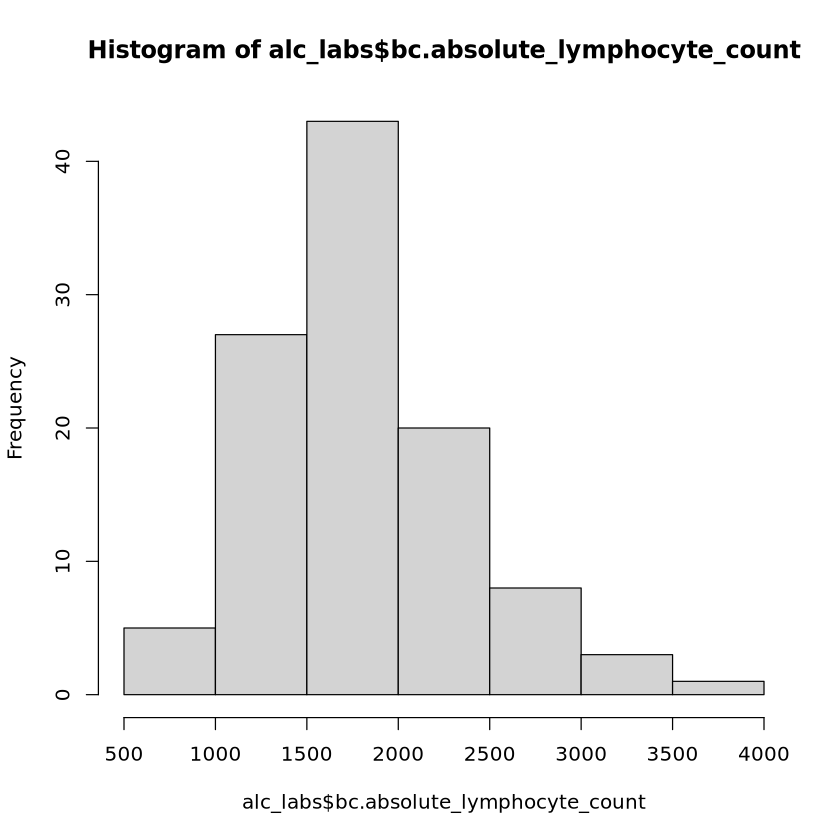

In [19]:
hist(alc_labs$bc.absolute_lymphocyte_count)

### Retrieve Cyanno Label information

These files provide ontological relationships between Cyanno cell labels and scRNA-seq labels. We'll incorporate these into the Cyanno label counts files to enable comparison between scRNA-seq and Cyanno results.

In [20]:
label_uuids <- list(
    "PB1" = list("3c7bdc9c-0531-405a-a944-19ffb7742c7d"),
    "PM1" = list("bec98f34-3578-409a-870d-a99f4e46e559"),
    "PS1" = list("201b9eaa-d7a7-477f-99c8-aef19e8bd947"),
    "PT1" = list("af34085f-ea51-4273-aebe-ab38196381fb")
)

In [21]:
label_files <- map(
    label_uuids,
    cacheFiles
)

[1] "downloading fileID 3c7bdc9c-0531-405a-a944-19ffb7742c7d"
[1] "downloading fileID bec98f34-3578-409a-870d-a99f4e46e559"
[1] "downloading fileID 201b9eaa-d7a7-477f-99c8-aef19e8bd947"
[1] "downloading fileID af34085f-ea51-4273-aebe-ab38196381fb"


In [22]:
label_dfs <- map(label_files, read.csv)

## Find flow cytometry data

### Cyanno Labeling Counts
fileType = FlowCytometry-summary-frequency-stats

There should be 4 files for each sample, one per Flow Cytometry panel; 432 in total.

In [23]:
freq_desc <- getFileDescriptors(
    fileType = "FlowCytometry-summary-frequency-stats",
    filter = list(
        sample.sampleKitGuid = as.list(sample_meta[["sample.sampleKitGuid"]])
    )
)

In [24]:
freq_desc <- fileDescToDataframe(freq_desc)
nrow(freq_desc)

[1] 516

Some freq will be from exactly the same aliquots as the scRNA-seq data.

We can match these based on specimen IDs:

In [25]:
freq_desc <- freq_desc %>%
  mutate(pbmc_sample_id = sub(".+(PB[0-9]+-[0-9]+).+", "\\1", file.name)) %>%
  mutate(file_date = sub(".+(20[0-9]{2}-[0-9]{2}-[0-9]{2}).+", "\\1", file.name)) %>%
  mutate(kit_panel = paste0(sample.sampleKitGuid, "_", file.panel))

In [26]:
matched_freq_desc <- freq_desc %>%
  filter(pbmc_sample_id %in% sample_meta$pbmc_sample_id)
nrow(matched_freq_desc)

[1] 0

Remove duplicates - in some cases, files were uploaded multiple times. We'll make sure that we take the most recent data available for each sample.

In [27]:
matched_freq_desc <- matched_freq_desc %>%
  arrange(desc(file_date)) %>%
  group_by(pbmc_sample_id, file.panel) %>%
  slice(1)

In [28]:
nrow(matched_freq_desc)

[1] 0

In [29]:
table(matched_freq_desc$file.panel)

< table of extent 0 >

In [30]:
length(unique(matched_freq_desc$sample.sampleKitGuid))

[1] 0

In some cases, the specific aliquot may differ, but data may be available from the same batch:

In [31]:
batch_freq_desc <- freq_desc %>%
  filter(!sample.sampleKitGuid %in% matched_freq_desc$sample.sampleKitGuid) %>%
  filter(file.batchID %in% sample_meta$file.batchID) %>%
  arrange(desc(file_date)) %>%
  group_by(sample.sampleKitGuid, file.panel) %>%
  slice(1)
nrow(batch_freq_desc)

[1] 0

In [32]:
table(batch_freq_desc$file.panel)

< table of extent 0 >

Some samples were run in separate batches. In these cases, we'll take the most recent file per sample kit for each file panel.

In [33]:
unmatched_freq_desc <- freq_desc %>%
  filter(!kit_panel %in% matched_freq_desc$kit_panel) %>%
  filter(!kit_panel %in% batch_freq_desc$kit_panel) %>%
  arrange(desc(file_date)) %>%
  group_by(sample.sampleKitGuid, file.panel) %>%
  slice(1)
nrow(unmatched_freq_desc)

[1] 432

In [34]:
table(unmatched_freq_desc$file.panel)


PB1 PM1 PS1 PT1 
108 108 108 108 

In [35]:
selected_freq_desc <- do.call(rbind, list(matched_freq_desc, batch_freq_desc, unmatched_freq_desc))

In [36]:
selected_freq_csv <- paste0("output/human_immune_health_atlas_flow-freq_file-meta_", Sys.Date(), ".csv")
write.csv(
    selected_freq_desc,
    selected_freq_csv,
    row.names = FALSE,
    quote = FALSE
)

Let's split these by panel and retrieve the data.

In [37]:
panel_freq <- split(selected_freq_desc, selected_freq_desc$file.panel)

In [38]:
freq_files <- map(
    panel_freq,
    function(df) {
        cacheFiles(as.list(df[["file.id"]]))
    }
)

[1] "downloading fileID ebbde65d-0a5a-40ce-9aa7-ce8ad5e4f673"
[1] "downloading fileID 14648c09-2f8d-4c87-bba3-5f91757a79cf"
[1] "downloading fileID 2a0da76c-b4b4-4492-96c6-99044f5800e1"
[1] "downloading fileID b4764ceb-4db1-4764-8c96-87b90187ca63"
[1] "downloading fileID 2e40c682-51ad-44af-87dc-24016713d2f4"
[1] "downloading fileID 09d5d2b4-2f32-4ca8-8150-5fe638da47b6"
[1] "downloading fileID 87c1358a-3d11-4380-a273-f8f202ec4545"
[1] "downloading fileID 84197123-6e65-49b6-896d-6e5de6674def"
[1] "downloading fileID 4e00f086-85f5-4967-913f-d8f1d2a95bcf"
[1] "downloading fileID 42607efd-0757-43ae-a29d-d7db13ce372d"
[1] "downloading fileID f6715bc3-4f3e-4272-8133-6e5650ac6d9f"
[1] "downloading fileID d6c01bbe-676e-4d52-af82-8cda7a07ca10"
[1] "downloading fileID 50604aab-29bb-4b63-a549-e55ea31f95fa"
[1] "downloading fileID d1adfe42-cc3f-49e9-9558-8cd1b0cb2742"
[1] "downloading fileID dd05056a-de0c-4b8c-bd33-3afa8a37c949"
[1] "downloading fileID 8e63753c-794c-41d4-b963-4f4282d3f93b"
[1] "dow

In [39]:
freq_files[[1]][1]

[1] "/home/workspace/input/1918706177/imm_age/ebbde65d-0a5a-40ce-9aa7-ce8ad5e4f673/automated/Cyanno/2024-01-04T23:20:16.385755344Z/Flow_Cyanno_PB1_PB00001-04_summary_frequency_stats.csv"

## Build DataFrame for each panel

In [40]:
panel_dfs <- map(
    freq_files,
    function(file_set) {
        map(file_set,
            function(file_name) {
                df <- read.csv(file_name)
                df$sample.sampleKitGuid <- sub("PB([0-9]+)-.+", "KT\\1", df$sample_id)
                df$file.id <- sub("/home/workspace/input/[0-9]+/[^/]+/(.+)/auto.+", "\\1", file_name)
                df$file.batchID <- selected_freq_desc$file.batchID[match(df$file.id, selected_freq_desc$file.id)]
                df$file.panel <- selected_freq_desc$file.panel[match(df$file.id, selected_freq_desc$file.id)]
                df
            }
        ) %>%
        list_rbind()
    }
)

### Add sample metadata

In [41]:
panel_dfs <- map(
    panel_dfs,
    left_join,
    sample_meta,
    by = "sample.sampleKitGuid"
)

### Add label conversions

In [42]:
names(panel_dfs)

[1] "PB1" "PM1" "PS1" "PT1"

In [43]:
panel_dfs <- map2(
    panel_dfs, label_dfs[names(panel_dfs)],
    left_join,
    by = c("l1_labels", "labels")
)

In [44]:
head(panel_dfs[[1]])

,labels,counts,frequency_live,total_counts,sample_id,barcode,l1_labels,sample.sampleKitGuid,file.id,file.batchID,⋯,specimen.specimenGuid,pipeline.fileGuid,CyAnno_L1,CyAnno_PB1,AIFI_L1_relationship,AIFI_L1,AIFI_L2_relationship,AIFI_L2,AIFI_L3_relationship,AIFI_L3
,<chr>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Unknown,92095,0.3106374654,296471,PB00001-04,ec37693cab5411eebe77a6ca3f1375ac,unknown,KT00001,ebbde65d-0a5a-40ce-9aa7-ce8ad5e4f673,B151,⋯,PB00001-01,fec489f9-9a74-4635-aa91-d2bf09d1faec,Unknown,Unknown,NA,NA,NA,NA,NA,NA
2,cd14_monocytes,39795,0.1342289802,296471,PB00001-04,ec376838ab5411eebe77a6ca3f1375ac,total_myeloid_cells,KT00001,ebbde65d-0a5a-40ce-9aa7-ce8ad5e4f673,B151,⋯,PB00001-01,fec489f9-9a74-4635-aa91-d2bf09d1faec,Total Myeloid cells,CD14 Monocytes,is_subset_of,Monocyte,is_equivalent_to,CD14 monocyte,NA,NA
3,debris,9112,0.0307348779,296471,PB00001-04,ec377152ab5411eebe77a6ca3f1375ac,debris,KT00001,ebbde65d-0a5a-40ce-9aa7-ce8ad5e4f673,B151,⋯,PB00001-01,fec489f9-9a74-4635-aa91-d2bf09d1faec,Debris,Debris,NA,NA,NA,NA,NA,NA
4,naive_b_cells,11464,0.0386682003,296471,PB00001-04,ec37698cab5411eebe77a6ca3f1375ac,total_b_cells,KT00001,ebbde65d-0a5a-40ce-9aa7-ce8ad5e4f673,B151,⋯,PB00001-01,fec489f9-9a74-4635-aa91-d2bf09d1faec,Total B cells,Naive B cells,is_subset_of,B cell,is_equivalent_to,Naive B cell,NA,NA
5,nk_cells,23962,0.0808240941,296471,PB00001-04,ec3769dcab5411eebe77a6ca3f1375ac,total_nk_cells,KT00001,ebbde65d-0a5a-40ce-9aa7-ce8ad5e4f673,B151,⋯,PB00001-01,fec489f9-9a74-4635-aa91-d2bf09d1faec,Total NK cells,NK cells,is_equivalent_to,NK cell,NA,NA,NA,NA
6,non_switched_effector_b_cells,145,0.0004890866,296471,PB00001-04,ec3a7d7aab5411eebe77a6ca3f1375ac,total_b_cells,KT00001,ebbde65d-0a5a-40ce-9aa7-ce8ad5e4f673,B151,⋯,PB00001-01,fec489f9-9a74-4635-aa91-d2bf09d1faec,Total B cells,Non-switched Effector B cells,is_subset_of,B cell,is_subset_of,Effector B cell,NA,NA


### Generate more specific fractions

In [45]:
panel_dfs <- map(
    panel_dfs,
    function(df) {
        df %>%
          group_by(sample.sampleKitGuid) %>%
          mutate(frac_live_events = counts / sum(counts)) %>%
          mutate(frac_cells = case_when(
              l1_labels == "unknown" ~ NA,
              l1_labels == "debris" ~ NA,
              TRUE ~ counts / sum(counts[!l1_labels %in% c("unknown", "debris")])
              )
          )
    }
)

In [46]:
panel_dfs[[1]] %>%
  select(labels, counts, frequency_live, total_counts, frac_live_events, frac_cells) %>%
  head(20)

Adding missing grouping variables: `sample.sampleKitGuid`


sample.sampleKitGuid,labels,counts,frequency_live,total_counts,frac_live_events,frac_cells
<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>
KT00001,Unknown,92095,0.3106374654,296471,0.3106374654,NA
KT00001,cd14_monocytes,39795,0.1342289802,296471,0.1342289802,0.2038010079
KT00001,debris,9112,0.0307348779,296471,0.0307348779,NA
KT00001,naive_b_cells,11464,0.0386682003,296471,0.0386682003,0.0587102589
KT00001,nk_cells,23962,0.0808240941,296471,0.0808240941,0.1227159128
KT00001,non_switched_effector_b_cells,145,0.0004890866,296471,0.0004890866,0.0007425844
KT00001,non_switched_memory_b_cells,2184,0.0073666564,296471,0.0073666564,0.0111848574
KT00001,other_b_cells,74,0.0002496028,296471,0.0002496028,0.0003789741
KT00001,plasmablasts,408,0.0013761886,296471,0.0013761886,0.0020894789


### Add ALC values and compute count estimates

In [47]:
panel_dfs <- map(
    panel_dfs,
    left_join,
    alc_labs,
    by = "sample.sampleKitGuid"
)

In [48]:
table(panel_dfs[[1]]$AIFI_L1)


  B cell Monocyte  NK cell   T cell 
     972      108      108      108 

In [49]:
panel_dfs <- map(
    panel_dfs,
    function(panel_df) {
        panel_df %>%
          group_by(sample.sampleKitGuid) %>%
          mutate(flow.lymphocyte_count = sum(counts[AIFI_L1 %in% c("B cell", "NK cell", "T cell")])) %>%
          mutate(alc_ratio = bc.absolute_lymphocyte_count / flow.lymphocyte_count) %>%
          mutate(alc = counts * alc_ratio) %>%
          ungroup()
    }
)

## Add CLR values

In [50]:
panel_dfs <- map(
    panel_dfs,
    function(panel_df) {
        clr_df <- panel_df %>%
          filter(!is.na(frac_cells)) %>%
          select(sample.sampleKitGuid, labels, frac_cells) %>%
          group_by(sample.sampleKitGuid) %>%
          mutate(clr = clr_transform(frac_cells)) %>%
          select(sample.sampleKitGuid, labels, clr)

        panel_df %>%
          left_join(clr_df, by = c("sample.sampleKitGuid", "labels"))
    }
)

### Select columns to retain

In [52]:
final_dfs <- map2(
    panel_dfs, names(panel_dfs),
    function(df, panel) {
        panel_prefix <- paste0("CyAnno_", panel, "_")
        name_lookup <- c("counts", "frac_live_events", "frac_cells", "alc", "clr")
        names(name_lookup) <- paste0(panel_prefix, name_lookup)
        name_lookup <- c(name_lookup, "specimen.specimenGuid" = "sample_id")
        
        df %>%
          select(
              file.id, file.batchID, file.panel,
              cohort.cohortGuid,
              subject.subjectGuid, subject.biologicalSex,
              subject.cmv, subject.bmi,
              subject.race, subject.ethnicity,
              subject.birthYear, subject.ageAtFirstDraw,
              sample.sampleKitGuid, sample.visitName, 
              sample.drawDate, sample.subjectAgeAtDraw,
              sample_id,
              CyAnno_L1, starts_with("CyAnno"),
              counts, frac_cells, frac_live_events,
              bc.absolute_lymphocyte_count, flow.lymphocyte_count, alc_ratio, alc, clr,
              AIFI_L1_relationship, AIFI_L1,
              AIFI_L2_relationship, AIFI_L2,
              AIFI_L3_relationship, AIFI_L3,
              file.id
          ) %>%
          rename(all_of(name_lookup))
    }
)

In [62]:
str(final_dfs[[1]])

tibble [1,512 × 33] (S3: tbl_df/tbl/data.frame)
 $ file.id                     : chr [1:1512] "ebbde65d-0a5a-40ce-9aa7-ce8ad5e4f673" "ebbde65d-0a5a-40ce-9aa7-ce8ad5e4f673" "ebbde65d-0a5a-40ce-9aa7-ce8ad5e4f673" "ebbde65d-0a5a-40ce-9aa7-ce8ad5e4f673" ...
 $ file.batchID                : chr [1:1512] "B151" "B151" "B151" "B151" ...
 $ file.panel                  : chr [1:1512] "PB1" "PB1" "PB1" "PB1" ...
 $ cohort.cohortGuid           : chr [1:1512] "BR1" "BR1" "BR1" "BR1" ...
 $ subject.subjectGuid         : chr [1:1512] "BR1001" "BR1001" "BR1001" "BR1001" ...
 $ subject.biologicalSex       : chr [1:1512] "Female" "Female" "Female" "Female" ...
 $ subject.cmv                 : chr [1:1512] "Negative" "Negative" "Negative" "Negative" ...
 $ subject.bmi                 : num [1:1512] 23 23 23 23 23 23 23 23 23 23 ...
 $ subject.race                : chr [1:1512] "Caucasian" "Caucasian" "Caucasian" "Caucasian" ...
 $ subject.ethnicity           : chr [1:1512] "Non-Hispanic origin" "Non-His

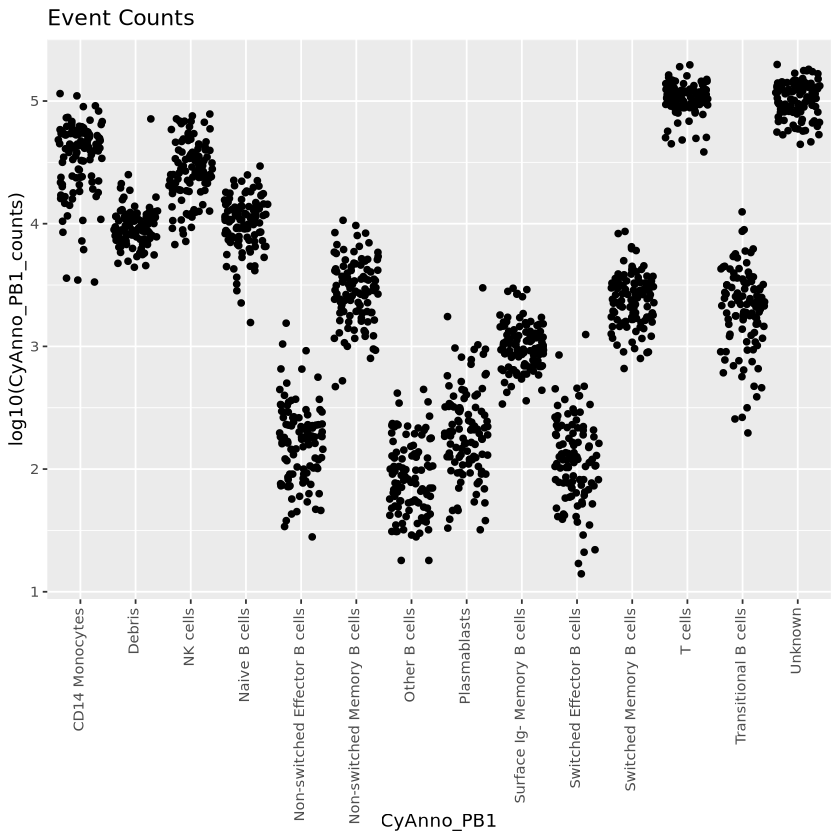

In [86]:
ggplot() +
  geom_jitter(
      data = test_data,
      aes(x = CyAnno_PB1,
          y = log10(CyAnno_PB1_counts))
  ) +
  theme(
      axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.3)
  ) +
  ggtitle("Event Counts")

Will miss 1 row for each population for the sample without an ALC (removed above)

Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


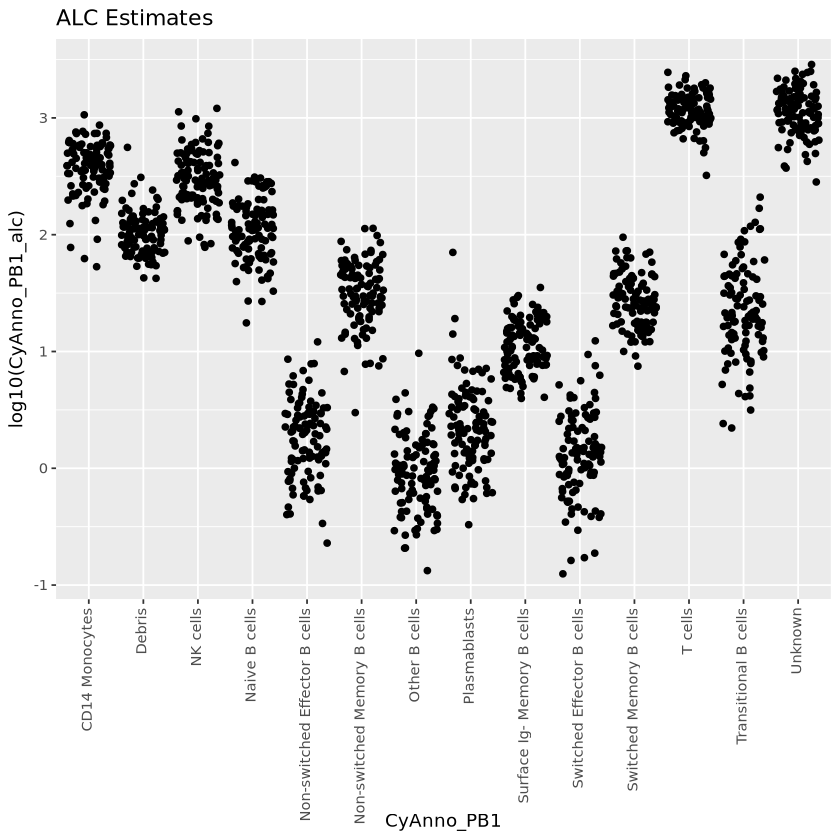

In [87]:
ggplot() +
  geom_jitter(
      data = test_data,
      aes(x = CyAnno_PB1,
          y = log10(CyAnno_PB1_alc))
  ) +
  theme(
      axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.3)
  ) +
  ggtitle("ALC Estimates")

Should miss 216 of the following because they're Unknown or Debris

Warning message:
“Removed 216 rows containing missing values or values outside the scale range
(`geom_point()`).”


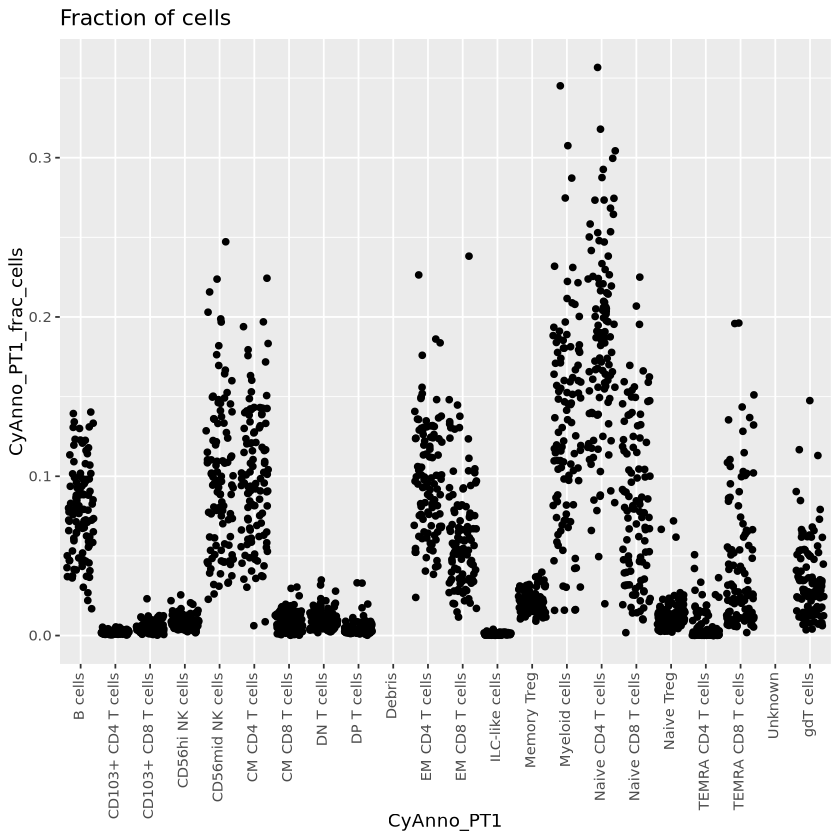

In [77]:
ggplot() +
  geom_jitter(
      data = test_data,
      aes(x = CyAnno_PB1,
          y = CyAnno_PB1_frac_cells)
  ) +
  theme(
      axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.3)
  ) + 
  ggtitle("Fraction of cells")

Warning message:
“Removed 216 rows containing missing values or values outside the scale range
(`geom_point()`).”


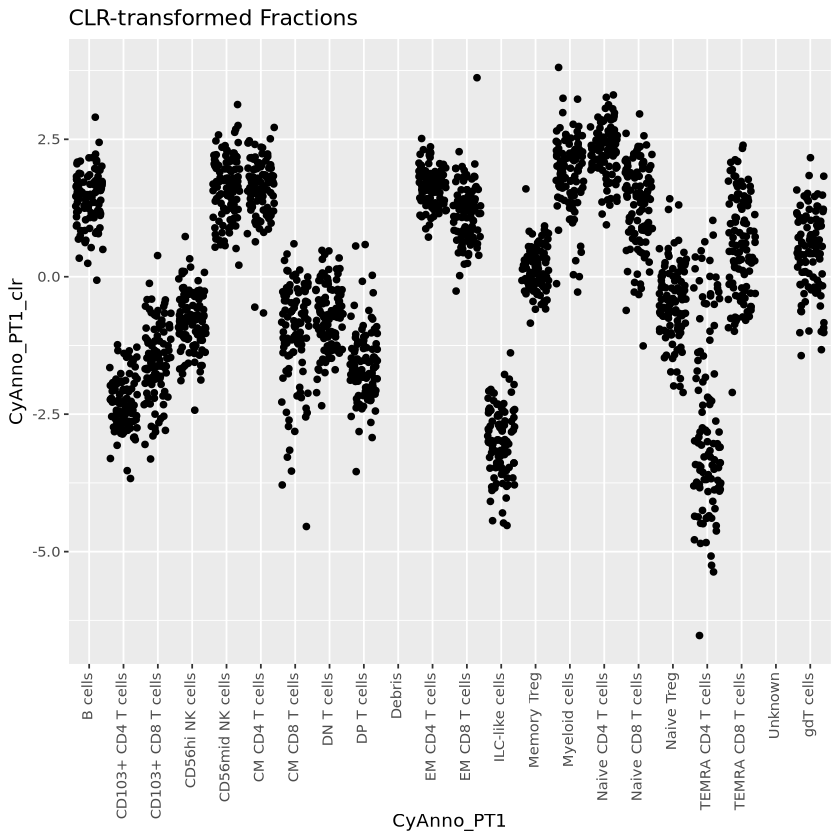

In [78]:
ggplot() +
  geom_jitter(
      data = test_data,
      aes(x = CyAnno_PB1,
          y = CyAnno_PB1_clr)
  ) +
  theme(
      axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.3)
  ) +
  ggtitle("CLR-transformed Fractions")

## Save outputs

In [98]:
names(final_dfs)

[1] "PB1" "PM1" "PS1" "PT1"

In [99]:
out_csv <- list(
    PB1 = paste("output/human_immune_health_atlas_cyanno-counts_PB1_", Sys.Date(), ".csv"),
    PM1 = paste("output/human_immune_health_atlas_cyanno-counts_PM1_", Sys.Date(), ".csv"),
    PS1 = paste("output/human_immune_health_atlas_cyanno-counts_PS1_", Sys.Date(), ".csv"),
    PT1 = paste("output/human_immune_health_atlas_cyanno-counts_PT1_", Sys.Date(), ".csv")
)

In [101]:
walk2(
    final_dfs, out_csv[names(final_dfs)],
    write.csv,
    quote = FALSE,
    row.names = FALSE
)

In [106]:
out_parquet <- list(
    PB1 = paste("output/human_immune_health_atlas_cyanno-counts_PB1_", Sys.Date(), ".parquet"),
    PM1 = paste("output/human_immune_health_atlas_cyanno-counts_PM1_", Sys.Date(), ".parquet"),
    PS1 = paste("output/human_immune_health_atlas_cyanno-counts_PS1_", Sys.Date(), ".parquet"),
    PT1 = paste("output/human_immune_health_atlas_cyanno-counts_PT1_", Sys.Date(), ".parquet")
)

In [107]:
walk2(
    final_dfs, out_parquet[names(final_dfs)],
    write_parquet
)

## Upload data to HISE

In [36]:
study_space_uuid <- "64097865-486d-43b3-8f94-74994e0a72e0"
title <- paste("Imm. Health Atlas Flow CyAnno Population Counts", Sys.Date())

In [37]:
search_id <- ids::proquint(n_words = 3)

In [43]:
search_id

[1] "dudan-dimuz-porih"

In [112]:
in_list <- c(
    list(labs_uuid),
    label_uuids,
    as.list(selected_freq_desc[["file.id"]])
)

In [115]:
out_list <- c(out_csv, out_parquet)

In [116]:
out_list

$PB1
[1] "output/human_immune_health_atlas_cyanno-counts_PB1_ 2025-01-04 .csv"

$PM1
[1] "output/human_immune_health_atlas_cyanno-counts_PM1_ 2025-01-04 .csv"

$PS1
[1] "output/human_immune_health_atlas_cyanno-counts_PS1_ 2025-01-04 .csv"

$PT1
[1] "output/human_immune_health_atlas_cyanno-counts_PT1_ 2025-01-04 .csv"

$PB1
[1] "output/human_immune_health_atlas_cyanno-counts_PB1_ 2025-01-04 .parquet"

$PM1
[1] "output/human_immune_health_atlas_cyanno-counts_PM1_ 2025-01-04 .parquet"

$PS1
[1] "output/human_immune_health_atlas_cyanno-counts_PS1_ 2025-01-04 .parquet"

$PT1
[1] "output/human_immune_health_atlas_cyanno-counts_PT1_ 2025-01-04 .parquet"

In [41]:
uploadFiles(
    files = out_list,
    studySpaceId = study_space_uuid,
    title = title,
    inputFileIds = in_list,
    store = "project",
    destination = search_id
)

$Message
[1] "General Okay-ness"

$VisualizationId
[1] "00000000-0000-0000-0000-000000000000"

$AbstractionId
[1] "00000000-0000-0000-0000-000000000000"

$TraceId
[1] "75ef4fa8-fa34-4eef-af91-9e19b3994916"

$ProcessId
[1] "5575e9e0-6115-4e4a-9f52-5fb023e0bce4"

$WorkflowId
[1] "f526ff55-fa34-48fa-8288-3b6562d8cf77"

$FileIds
$FileIds[[1]]
[1] "7fae0c52-fe3c-494c-a4ad-4235a1eb3b41"

$FileIds[[2]]
[1] "87b8dd66-14af-4243-961e-e1eace33202a"

$FileIds[[3]]
[1] "c5fe34ae-4251-4dc9-912d-2dbb85afe418"

$FileIds[[4]]
[1] "81929c4f-d3f4-415d-9761-8e6f40ed617f"

$FileIds[[5]]
[1] "2cc9a15f-28f3-43ab-b2e2-5e7c0d0490a2"

In [42]:
sessionInfo()

R version 4.1.3 (2022-03-10)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 24.04 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/r_flow/lib/libopenblasp-r0.3.20.so

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] purrr_0.3.4 dplyr_1.0.8 hise_2.16.0

loaded via a namespace (and not attached):
 [1] Rcpp_1.0.8.3     plyr_1.8.7       pillar_1.7.0     compiler_4.1.3  
 [5] base64enc_0.1-3  bitops_1.0-7     tools_4.1.3      digest_0.6.29   
 [9] uuid_1.1-0       jsonlite_1.8.0   evaluate_0.15    lifecycle_1.0.1 
[13] tibble_3.1.6     pkgconfig_2.0.3  rlang_1.0.2      IRdisplay_1.1   
[17] cli_3.2.0        DBI